### Project Setup

In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path().resolve().parent))
from TSC_Python import TSC, TSCResult, TSC_MLX

In [2]:
import mlx.core as mx
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm, trange
from matplotlib.colors import ListedColormap, BoundaryNorm
import ipywidgets as widgets

### File Location

In [3]:
ROOT = Path().resolve().parent
MAT_DIR = ROOT / "MAT Files"
GT_DIR = ROOT / "GT Files"

### Datasets - Files & Keys

In [4]:
DATASETS = {
    "Pavia": {
        "data_file": "Pavia.mat",
        "gt_file":   "Pavia_gt.mat",
        "data_key":  "pavia",
        "gt_key":    "pavia_gt",
    },
    "PaviaUni": {
        "data_file": "PaviaUni.mat",
        "gt_file":   "PaviaU_gt.mat",
        "data_key":  "paviaU",
        "gt_key":    "paviaU_gt",
    },
    "Salinas": {
        "data_file":  "Salinas_corrected.mat",
        "gt_file":    "Salinas_gt.mat",
        "data_key":   "salinas_corrected",
        "gt_key":     "salinas_gt",
    },
    "Indian pines":{
        "data_file":  "Indian_pines.mat",
        "gt_file":    "Indian_pines_gt.mat",
        "data_key":   "indian_pines",
        "gt_key":     "indian_pines_gt",
    }
}

In [5]:
DEFAULT_DS = "Pavia"

ds = widgets.Dropdown(options=list(DATASETS.keys()),
                      value=DEFAULT_DS,
                      description="Dataset:")
out = widgets.Output()

display(ds, out)

Dropdown(description='Dataset:', options=('Pavia', 'PaviaUni', 'Salinas', 'Indian pines'), value='Pavia')

Output()

In [6]:
keys = DATASETS[ds.value]

In [7]:
keys

{'data_file': 'Pavia.mat',
 'gt_file': 'Pavia_gt.mat',
 'data_key': 'pavia',
 'gt_key': 'pavia_gt'}



## Hyperspectral Image Cube

In [8]:
def load_ds(name: str):
    cfg = DATASETS[name]
    data_mat = sio.loadmat(MAT_DIR / cfg["data_file"])
    gt_mat = sio.loadmat(GT_DIR / cfg["gt_file"])
    globals()["data_cube"] = data_mat[cfg["data_key"]]
    globals()["gt_data"] = gt_mat[cfg["gt_key"]]
    with out:
        out.clear_output(wait=True)
        print(f"Loaded {name}: X {data_cube.shape}, GT {gt_data.shape}")


In [9]:
def _on_change(change):
    if change["name"] == "value":
        load_ds(change["new"])

In [10]:
ds.observe(_on_change, names="value")

In [11]:
load_ds(ds.value)

## Ground Truth Data

In [12]:
gt_data

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1096, 715), dtype=uint8)

In [13]:
gt_data.shape

(1096, 715)

In [14]:
gt_labels = np.sort(np.unique(gt_data))

In [15]:
num_labels = len(gt_labels)

In [16]:
bg_indices = gt_data == 0

In [17]:
filter = mx.ones([data_cube.shape[0], data_cube.shape[1]])

In [18]:
mask = mx.where(bg_indices, 0.0, filter)

In [19]:
mask3d = mask[..., None]

In [20]:
masked_cube = mx.multiply(data_cube, mask3d)

In [21]:
masked_cube_reshaped = mx.reshape(masked_cube, (masked_cube.shape[0]*masked_cube.shape[1], masked_cube.shape[2]))

In [22]:
cube_np = np.array(masked_cube_reshaped)
nonzero_mask = np.any(cube_np != 0, axis=1)
filtered_np = cube_np[nonzero_mask]
filtered_pixels = mx.array(filtered_np)

### Fit the Model

In [23]:
model = TSC(
    n_clusters = num_labels-1,
    verbose = 2,
    random_state=10
)

In [24]:
%%time
model.fit(filtered_pixels.T)

[TSC] Converting input to NumPy array with dtype=float64, shape=(102, 148152)
Running TSC with n_clusters=9, max_nz=15, max_chunksize=1024, n_init=20, max_iter=100
[TSC] Building affinity matrix | N=148152, q=15, chunksize=1024, n_chunks=145, backend=CPU


TSC affinity:   0%|          | 0/145 [00:00<?, ?it/s]

[TSC] Affinity construction finished | nnz=3472838
[TSC] Computing spectral embedding | nev=9, mode=fixed K=9
[TSC] Using sparse eigsh
[TSC] Running k-means on embedding with shape=(148152, 9), n_clusters=9, n_init=20, max_iter=100
Finished TSC with n_clusters_=9
CPU times: user 13min 6s, sys: 2min 13s, total: 15min 19s
Wall time: 11min 41s


In [25]:
labels = model.labels_

In [26]:
for k in range(1, num_labels):
    ilist = np.nonzero(labels == k)[0]
    print(f"Cluster {k}: {ilist}")

Cluster 1: [     0      1      2 ... 104696 104808 104918]
Cluster 2: [    68   1896   1897 ... 144861 144891 144892]
Cluster 3: [    62     63     64 ... 148140 148144 148145]
Cluster 4: [   137    138    139 ... 148149 148150 148151]
Cluster 5: [   136    322    467 ... 148141 148142 148143]
Cluster 6: [   134    203    320 ... 145606 145705 145762]
Cluster 7: [    67   4445   4614 ... 144717 144718 144742]
Cluster 8: [  2179   2631   2633 ... 144896 144897 144898]
Cluster 9: [   323    324    468 ... 147519 147520 147521]


In [27]:
label_px = gt_data > 0 # Returns a boolean map with background pixels stored as False

clustermap = np.zeros_like(gt_data, dtype=np.int32) # Create a zero filled 2D array size of gt_data

clustermap[label_px] = labels # Fills the foreground pixels

In [28]:
def plot_gt_vs_clusters(gt_data, clustermap, title_left="Ground Truth", title_right="TSC Clustering Results"):
    gt_max = int(np.max(gt_data))
    km_max = int(np.max(clustermap))
    n_classes = max(gt_max, km_max)

    # color 0 = background (black); then categorical colors for 1..n_classes
    base = plt.cm.tab20.colors  # plenty of distinct colors
    palette = ['black'] + [base[i % len(base)] for i in range(n_classes)]
    cmap = ListedColormap(palette)
    norm = BoundaryNorm(np.arange(n_classes + 2) - 0.5, cmap.N)  # hard bins at integers

    fig, axes = plt.subplots(1, 2, figsize=(9, 7), constrained_layout=True)

    im0 = axes[0].imshow(gt_data, cmap=cmap, norm=norm, interpolation='nearest')
    axes[0].set_title(title_left, fontsize=16)
    axes[0].axis('equal'); axes[0].set_xticks([]); axes[0].set_yticks([])

    im1 = axes[1].imshow(clustermap, cmap=cmap, norm=norm, interpolation='nearest')
    axes[1].set_title(title_right, fontsize=16)
    axes[1].axis('equal'); axes[1].set_xticks([]); axes[1].set_yticks([])

    # one colorbar per panel with integer ticks (0..n_classes)
    ticks = np.arange(0, n_classes + 1, 1)
    cbar0 = fig.colorbar(im0, ax=axes[0], ticks=ticks, orientation='horizontal', fraction=0.046, pad=0.05)
    cbar1 = fig.colorbar(im1, ax=axes[1], ticks=ticks, orientation='horizontal', fraction=0.046, pad=0.05)

    plt.show()

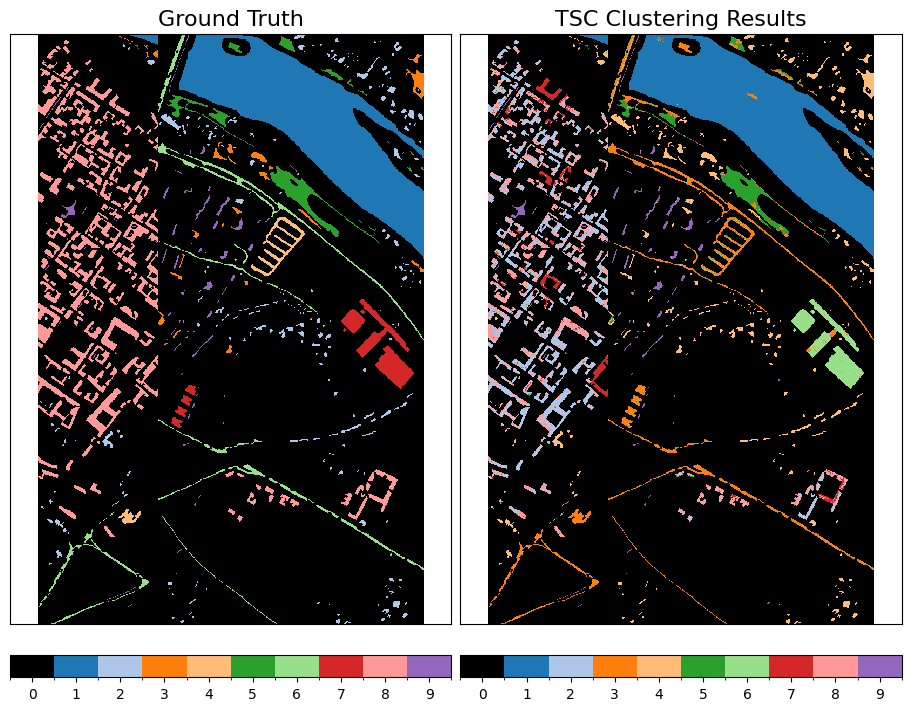

In [29]:
plot_gt_vs_clusters(gt_data, clustermap)

In [30]:
model_gpu = TSC_MLX(
    n_clusters = num_labels-1,
    use_gpu = True,
    verbose = 2,
    random_state=10
)

In [31]:
%%time
model_gpu.fit(filtered_pixels.T)

[TSC] Converting input to MLX array on gpu with dtype=mlx.core.float32, shape=(102, 148152)
Running TSC with n_clusters=9, max_nz=15, max_chunksize=1024, n_init=20, max_iter=100
[TSC] Building affinity matrix | N = 148152, q=15, chunksize=1024n_chunks=145, backend=GPU


TSC affinity:   0%|          | 0/145 [00:00<?, ?it/s]

[TSC] Affinity construction finished | nnz=3472818
[TSC] Computing spectral embedding | nev=9, mode=fixed K=9
[TSC] Running k-means on embedding with shape=(148152, 9), n_clusters=9, n_init=20, max_iter=100
Finished TSC with n_clusters_=9
CPU times: user 9min 43s, sys: 30.6 s, total: 10min 14s
Wall time: 11min 10s


In [32]:
labels_gpu = model_gpu.labels_

In [33]:
for k in range(1, num_labels):
    ilist = np.nonzero(labels_gpu == k)[0]
    print(f"Cluster {k}: {ilist}")

Cluster 1: [  2179   2631   2633 ... 144896 144897 144898]
Cluster 2: [     0      1      2 ... 104696 104808 104918]
Cluster 3: [    62     63     64 ... 148140 148144 148145]
Cluster 4: [   134    203    320 ... 145606 145705 145762]
Cluster 5: [   137    138    139 ... 148149 148150 148151]
Cluster 6: [   136    322    467 ... 148141 148142 148143]
Cluster 7: [   323    324    468 ... 147519 147520 147521]
Cluster 8: [    67   4445   4614 ... 144717 144718 144742]
Cluster 9: [    68   1896   1897 ... 144861 144891 144892]


In [34]:
label_px = gt_data > 0 # Returns a boolean map with background pixels stored as False

clustermap_gpu = np.zeros_like(gt_data, dtype=np.int32) # Create a zero filled 2D array size of gt_data

clustermap_gpu[label_px] = labels_gpu # Fills the foreground pixels

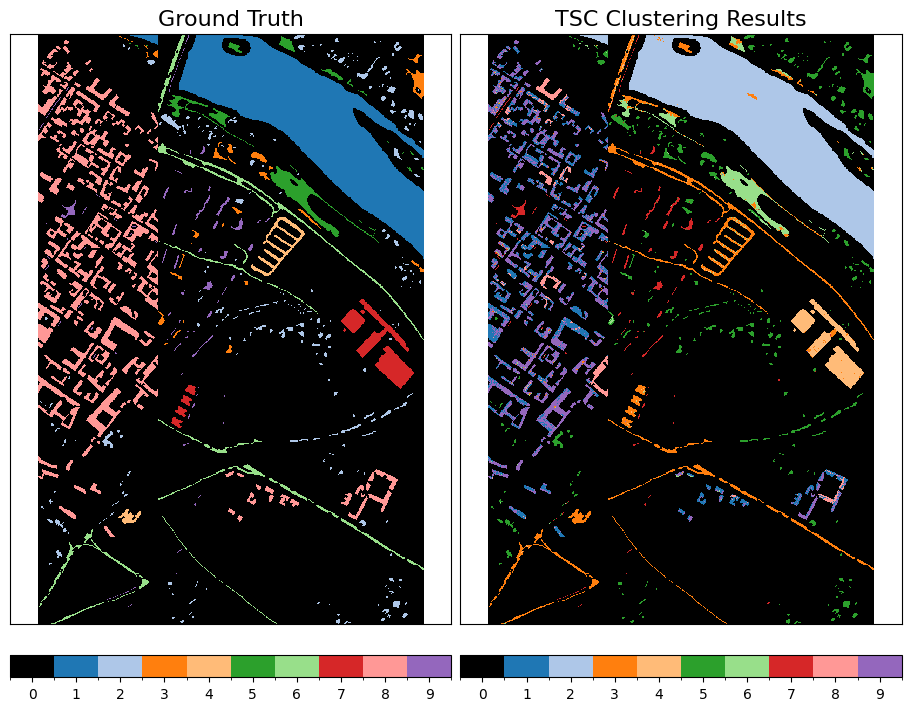

In [35]:
plot_gt_vs_clusters(gt_data, clustermap_gpu)